In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime as dt
from metpy.units import units
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [18]:
%%time 

ds = xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",
)

print(f'size: {ds.nbytes / (1024 ** 4)} TB')

size: 863.106730104857 TB
CPU times: user 86.6 ms, sys: 25.4 ms, total: 112 ms
Wall time: 1.35 s


In [33]:
lonW = -77.7
lonE = -73.7
latS = 42.6
latN = 44.6
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2 

# Recall that in ERA5, longitudes run between 0 and 360, not -180 and 180
if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
expand = 1
latRange = np.arange(latS - expand,latN + expand,.25) # expand the data range a bit beyond the plot range
lonRange = np.arange((lonW - expand),(lonE + expand),.25) # Need to match longitude values to those of the coordinate variable

# Date/Time specification; I was born on October 5th, 2000 at, again according to my mom, around 12:30 PM. 
Year = 2023
Month = 8
Day = 7
Hour = 23
Minute = 0
dateTime = dt(Year,Month,Day,Hour)
timeStr = dateTime.strftime("%Y-%m-%d %H%M UTC")
timeStr

'2023-08-07 2300 UTC'

In [34]:
ds

<xarray.Dataset> Size: 949TB
Dimensions:        (valid_time: 751680, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-09-30T...
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [35]:
%%time 
use_DE = True
if (use_DE):
    v = ds['v'].sel(valid_time=dateTime,latitude=latRange,longitude=lonRange, method='nearest')
else:
    v = ds['northward_wind'].sel(time=dateTime,latitude=latRange,longitude=lonRange)

v

CPU times: user 3.83 s, sys: 259 ms, total: 4.09 s
Wall time: 4.1 s


<xarray.DataArray 'v' (isobaricInhPa: 19, latitude: 16, longitude: 24)> Size: 29kB
dask.array<getitem, shape=(19, 16, 24), dtype=float32, chunksize=(1, 16, 24), chunktype=numpy.ndarray>
Coordinates:
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 128B 41.5 41.75 42.0 ... 44.75 45.0 45.25
  * longitude      (longitude) float64 192B 281.2 281.5 281.8 ... 286.8 287.0
    number         int64 8B ...
    valid_time     datetime64[ns] 8B 2023-08-07T23:00:00
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              northward_wind
    GRIB_cfVarName:                           v
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_units:                               m s**-1
    GRIB_uvRelativeToGrid:                    0
    long_name:                                V component of wind
    standard_name:                            northward_wind
    units:                                    m s**-1

In [36]:
print(v.values)

[[[ 1.9902344   1.8779297   1.7548828  ...  3.2734375   3.5859375
    4.3710938 ]
  [ 2.0488281   1.9707031   1.8378906  ...  3.7226562   3.6855469
    3.8046875 ]
  [ 1.3886719   1.5458984   1.4511719  ...  3.7773438   3.671875
    3.828125  ]
  ...
  [ 0.98095703  0.95654297  0.94384766 ...  2.296875    2.90625
    2.8242188 ]
  [ 0.89208984  0.91064453  0.86376953 ...  1.9316406   2.609375
    2.6855469 ]
  [ 0.9458008   0.7504883   0.6176758  ...  1.7363281   2.1738281
    2.125     ]]

 [[ 5.921875    5.          4.6289062  ... 17.28125    17.40625
   17.296875  ]
  [ 5.9257812   5.2421875   4.6679688  ... 17.46875    17.203125
   17.484375  ]
  [ 3.9609375   4.5976562   4.4414062  ... 17.34375    16.1875
   16.828125  ]
  ...
  [ 4.1796875   4.0898438   3.9804688  ... 14.6875     16.78125
   15.734375  ]
  [ 4.7929688   4.6132812   4.515625   ... 14.875      16.109375
   15.8515625 ]
  [ 5.171875    4.6640625   4.4023438  ... 13.71875    14.5390625
   14.9453125 ]]

 [[ 4.2578125

In [37]:
target_pressure = 1000 * units.hPa 
v_selected_level = v.sel(isobaricInhPa=target_pressure, method='nearest')

print("Shape after selecting 1000 hPa level:", v_selected_level.shape)

Shape after selecting 1000 hPa level: (16, 24)


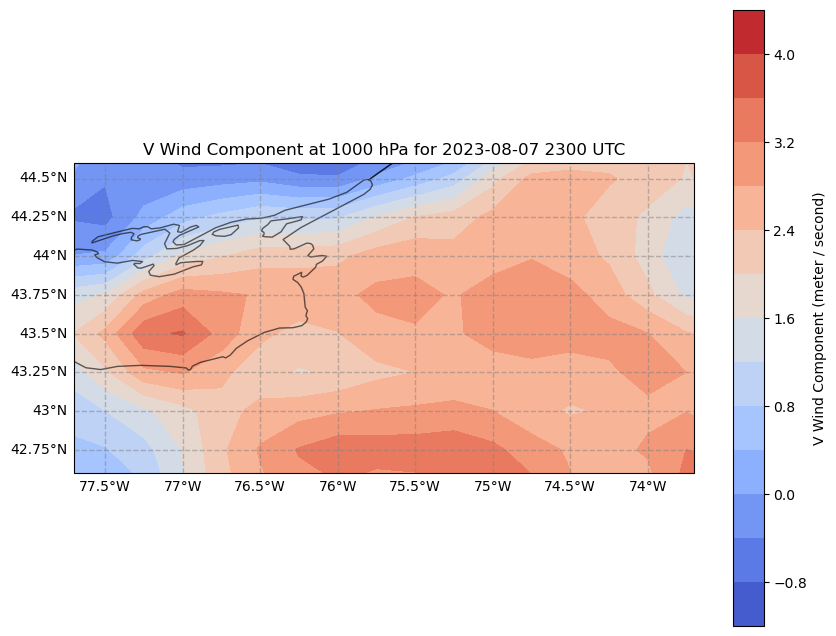

In [39]:
datacrs = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=datacrs) # Or datacrs

ax.set_extent([lonW, lonE, latS, latN], crs=datacrs)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', alpha=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# This is the line that generates the error
cf = ax.contourf(v_selected_level.longitude, v_selected_level.latitude, v_selected_level,
                 levels=15, cmap='coolwarm', transform=datacrs)

# Add a colorbar
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', 
                    label=f'V Wind Component ({v_selected_level.metpy.units})') 

# Add a title
level_val = v_selected_level.isobaricInhPa.item() # Get the exact value of the level
ax.set_title(f'V Wind Component at {level_val:.0f} hPa for {timeStr}')

plt.show()

In [9]:
if (use_DE):
    vert = ds['w'].sel(valid_time=dateTime,latitude=latRange,longitude=lonRange, method='nearest')
else:
    vert = ds['lagrangian_tendency_of_air_pressure'].sel(time=dateTime,latitude=latRange,longitude=lonRange)

vert

<xarray.DataArray 'w' (isobaricInhPa: 19, latitude: 16, longitude: 24)> Size: 29kB
dask.array<getitem, shape=(19, 16, 24), dtype=float32, chunksize=(1, 16, 24), chunktype=numpy.ndarray>
Coordinates:
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 128B 41.5 41.75 42.0 ... 44.75 45.0 45.25
  * longitude      (longitude) float64 192B 281.2 281.5 281.8 ... 286.8 287.0
    number         int64 8B ...
    valid_time     datetime64[ns] 8B 2023-08-07T23:00:00
Attributes: (12/31)
    GRIB_NV:                                  0
    GRIB_Nx:                                  1440
    GRIB_Ny:                                  721
    GRIB_cfName:                              lagrangian_tendency_of_air_pres...
    GRIB_cfVarName:                           w
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_units:                               Pa s**-1
    GRIB_uvRelativeToGrid:                    0
    long_name:                                Vertical velocity
    standard_name:                            lagrangian_tendency_of_air_pres...
    units:                                    Pa s**-1

In [10]:
vert_hpa = vert.metpy.convert_units('hPa/s')

In [11]:
print(vert_hpa.values)

[[[ 1.47094717e-04 -4.22973622e-04 -4.43725585e-04 ... -7.53784145e-04
   -2.08984362e-03 -2.14599608e-03]
  [ 2.99682608e-04 -3.25317378e-04 -5.55419902e-05 ...  7.04956066e-04
   -1.65527337e-03 -2.57080072e-03]
  [ 1.88598628e-04 -1.89819330e-04  1.45874015e-04 ...  1.77978515e-03
   -6.15844736e-04 -2.97851558e-03]
  ...
  [-3.03344714e-04 -2.44750961e-04 -2.27661134e-04 ... -1.79809565e-03
    1.22131349e-03  3.37890629e-03]
  [-1.81274416e-04 -1.25122067e-04 -1.76391593e-04 ... -9.82055673e-04
    9.69848596e-04  2.80761719e-03]
  [ 9.21630854e-05  1.49536136e-04 -5.31005862e-05 ... -9.70458932e-05
    5.74340811e-04  1.89331046e-03]]

 [[-6.95190392e-04 -7.36694317e-04 -2.26440417e-04 ... -3.08593735e-03
   -5.91308577e-03 -4.02587885e-03]
  [-6.84204104e-04 -3.02124012e-04 -2.00805662e-04 ...  2.08984362e-03
   -4.99511696e-03 -5.15624974e-03]
  [-2.22778320e-03 -6.50024391e-04 -1.64699559e-05 ...  5.59570314e-03
   -2.70263664e-03 -7.36328121e-03]
  ...
  [-1.57958979e-03 -1.0

In [12]:
target_pressure = 500 * units.hPa 
vert_selected_level = vert_hpa.sel(isobaricInhPa=target_pressure, method='nearest')

print("Shape after selecting 500 hPa level:", vert_selected_level.shape) # Expected: (16, 24)

Shape after selecting 500 hPa level: (16, 24)


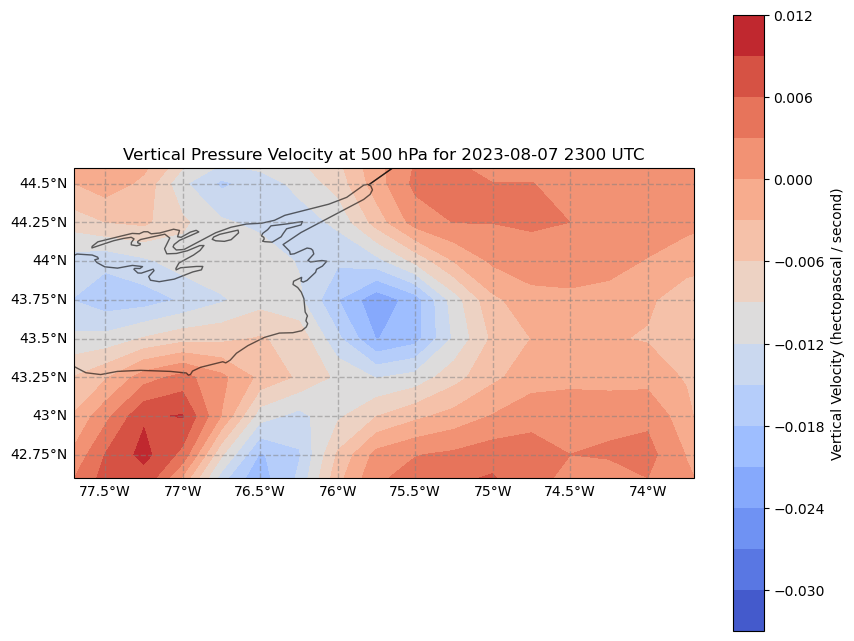

In [13]:
datacrs = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=datacrs) # Or datacrs

ax.set_extent([lonW, lonE, latS, latN], crs=datacrs)
ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor='black', alpha=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# This is the line that generates the error
cf = ax.contourf(vert_selected_level.longitude, vert_selected_level.latitude, vert_selected_level,
                 levels=15, cmap='coolwarm', transform=datacrs)

# Add a colorbar
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', 
                    label=f'Vertical Velocity ({vert_selected_level.metpy.units})') 

# Add a title
level_val = vert_selected_level.isobaricInhPa.item() # Get the exact value of the level
ax.set_title(f'Vertical Pressure Velocity at {level_val:.0f} hPa for {timeStr}')

plt.show()